# L3 · Notebook 03 — $V^*$ 唯一，但 $\pi^*$ 不一定

## 教学目标

**关键定理**：MDP 在 γ<1 下，$V^*$ 唯一存在；但**最优策略 $\pi^*$ 可能不唯一**——多个 $a$ 同时取得 $\arg\max_a Q^*(s, a)$。

1. 找出 GridWorld 中存在多个最优动作的状态
2. 构造对称环境验证：旋转对称的迷宫，多个等距路径都最优
3. 比较两个不同的 $\pi^*_a, \pi^*_b$，确认它们的 $V^{\pi^*_a} = V^{\pi^*_b} = V^*$
4. 思考：贪婪 tie-breaking 对 ε-贪婪算法（L6/L7）的影响

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from shared.grid_world import GridWorld, GridConfig
from shared.plotting import plot_value_heatmap, plot_policy_arrows, setup_chinese_font

setup_chinese_font()
env = GridWorld()
V_star, _, _ = env.value_iteration(tol=1e-12)
Q_star = env.compute_q_table(V_star)
print(f'|S|×|A| = {Q_star.shape}, γ={env.cfg.gamma}')

|S|×|A| = (25, 5), γ=0.9


## 1. 找出有多个最优动作的状态

对每个 s，看 $\arg\max_a Q^*(s, a)$ 是否唯一（用 1e-9 容忍数值误差）。

In [2]:
tol = 1e-9
ties = []
for s in env.all_states():
    i = env.state_index(s)
    q = Q_star[i]
    q_max = q.max()
    optimal_actions = [env.actions[k] for k in range(len(q)) if q[k] >= q_max - tol]
    if len(optimal_actions) > 1:
        ties.append((env.display_index(s), s, optimal_actions, q_max))

print(f'有 {len(ties)} 个状态存在多个最优动作:')
for s_i, s, acts, q in ties[:15]:
    print(f'  s{s_i:>3} {s}:  最优 a ∈ {acts},  Q* = {q:+.4f}')

有 5 个状态存在多个最优动作:
  s  3 (0, 2):  最优 a ∈ ['left', 'right'],  Q* = +0.4305
  s  4 (0, 3):  最优 a ∈ ['down', 'right'],  Q* = +0.4783
  s  7 (1, 1):  最优 a ∈ ['down', 'left'],  Q* = +0.5314
  s  9 (1, 3):  最优 a ∈ ['down', 'right'],  Q* = +0.5314
  s 18 (3, 2):  最优 a ∈ ['up', 'down', 'left', 'right', 'stay'],  Q* = +0.0000


## 2. 构造对称环境：4 个等距目标

In [3]:
# 5×5 居中地图：(2,2)=中心，(0,0)/(0,4)/(4,0)/(4,4) 4 个等距目标
# 在 GridConfig 里 forbidden=空, target=四角
# 但 GridConfig.target 只支持单目标 → 改造为多目标版本（自定义 step）
from shared.grid_world import ACTION_DELTAS, ACTIONS

class SymmetricEnv:
    def __init__(self, gamma=0.9):
        self.n_rows = 5; self.n_cols = 5
        self.targets = {(0, 0), (0, 4), (4, 0), (4, 4)}
        self.gamma = gamma
        self.actions = list(ACTIONS)
        self.n_states = self.n_rows * self.n_cols
        self.n_actions = len(self.actions)
        self._states = [(r, c) for r in range(5) for c in range(5)]
        self._idx = {s: i for i, s in enumerate(self._states)}
    def all_states(self): return list(self._states)
    def state_index(self, s): return self._idx[s]
    def step(self, s, a):
        if s in self.targets:
            return s, 0.0, True
        dr, dc = ACTION_DELTAS[a]
        nr, nc = s[0]+dr, s[1]+dc
        if not (0 <= nr < 5 and 0 <= nc < 5):
            return s, -1.0, False
        s2 = (nr, nc)
        if s2 in self.targets:
            return s2, 1.0, True
        return s2, 0.0, False
    def compute_q_table(self, V):
        Q = np.zeros((self.n_states, self.n_actions))
        for s in self._states:
            i = self.state_index(s)
            for ai, a in enumerate(self.actions):
                s2, r, _ = self.step(s, a)
                Q[i, ai] = r + self.gamma * V[self.state_index(s2)]
        return Q
    def value_iteration(self, tol=1e-12, max_iter=500):
        V = np.zeros(self.n_states)
        for _ in range(max_iter):
            Q = self.compute_q_table(V)
            V_new = Q.max(axis=1)
            if np.max(np.abs(V_new - V)) < tol:
                break
            V = V_new
        return V

sym = SymmetricEnv(gamma=0.9)
V_sym = sym.value_iteration()
Q_sym = sym.compute_q_table(V_sym)
print('对称环境 V* (5×5):')
print(V_sym.reshape(5, 5).round(3))
print('\n中心 s=(2,2) 的 Q 值 (应当 4 个移动动作几乎相等)：')
for ai, a in enumerate(sym.actions):
    print(f'  Q*((2,2), {a:>5}) = {Q_sym[sym.state_index((2,2)), ai]:+.6f}')

对称环境 V* (5×5):
[[0.    1.    0.9   1.    0.   ]
 [1.    0.9   0.81  0.9   1.   ]
 [0.9   0.81  0.729 0.81  0.9  ]
 [1.    0.9   0.81  0.9   1.   ]
 [0.    1.    0.9   1.    0.   ]]

中心 s=(2,2) 的 Q 值 (应当 4 个移动动作几乎相等)：
  Q*((2,2),    up) = +0.729000
  Q*((2,2),  down) = +0.729000
  Q*((2,2),  left) = +0.729000
  Q*((2,2), right) = +0.729000
  Q*((2,2),  stay) = +0.656100


**观察**：在对称中心 (2,2)，4 个移动方向的 Q* 完全相等 → 4 个动作都最优 → 4! 种 $\pi^*$ 都正确。

## 3. 两种不同的 $\pi^*$ 给出相同 $V$

In [4]:
# 策略 A：tie 时优先选 up
# 策略 B：tie 时优先选 right
def greedy_with_priority(env, Q, priority_order):
    pi = {}
    for s in env.all_states():
        i = env.state_index(s)
        q = Q[i]
        best = q.max()
        # 在并列里按 priority_order 选
        candidates = [a for ai, a in enumerate(env.actions) if q[ai] >= best - 1e-9]
        for a in priority_order:
            if a in candidates:
                pi[s] = a
                break
        else:
            pi[s] = candidates[0]
    return pi

pi_A = greedy_with_priority(sym, Q_sym, ['up', 'right', 'down', 'left', 'stay'])
pi_B = greedy_with_priority(sym, Q_sym, ['right', 'down', 'left', 'up', 'stay'])

diff_states = [s for s in sym.all_states() if pi_A[s] != pi_B[s]]
print(f'策略 A 与 B 在 {len(diff_states)} 个状态上选不同动作：')
for s in diff_states[:8]:
    print(f'  s={s}: A 选 {pi_A[s]:>5}, B 选 {pi_B[s]:>5}')

策略 A 与 B 在 12 个状态上选不同动作：
  s=(0, 0): A 选    up, B 选 right
  s=(0, 4): A 选    up, B 选 right
  s=(1, 1): A 选    up, B 选  left
  s=(1, 2): A 选    up, B 选 right
  s=(1, 3): A 选    up, B 选 right
  s=(2, 0): A 选    up, B 选  down
  s=(2, 1): A 选    up, B 选  down
  s=(2, 2): A 选    up, B 选 right


用迭代评估检查两个不同 π 的 v 值：理论上应当相同（因为它们都是 $\pi^*$）。

In [5]:
def eval_policy(env, pi, gamma=0.9, tol=1e-12, max_iter=2000):
    V = np.zeros(env.n_states)
    for _ in range(max_iter):
        Q = env.compute_q_table(V)
        V_new = np.zeros(env.n_states)
        for s in env.all_states():
            i = env.state_index(s)
            ai = env.actions.index(pi[s])
            V_new[i] = Q[i, ai]
        if np.max(np.abs(V_new - V)) < tol:
            break
        V = V_new
    return V

V_A = eval_policy(sym, pi_A)
V_B = eval_policy(sym, pi_B)
print(f'||V_A - V_B||_∞ = {np.max(np.abs(V_A - V_B)):.2e}  (理论应为 0)')
print(f'||V_A - V_sym||_∞ = {np.max(np.abs(V_A - V_sym)):.2e}')

||V_A - V_B||_∞ = 0.00e+00  (理论应为 0)
||V_A - V_sym||_∞ = 0.00e+00


## 4. 可视化：两个 π* 的箭头图（不同但等价）

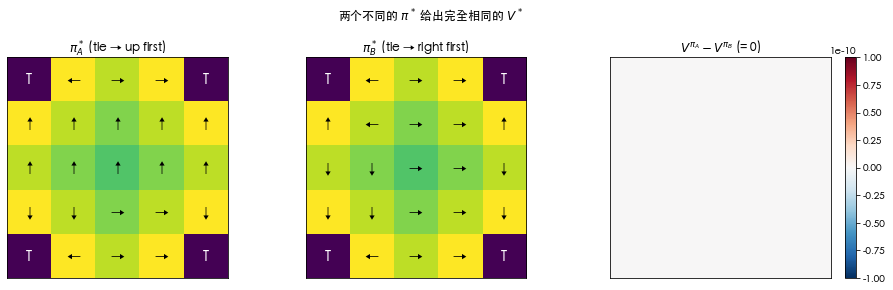

In [6]:
from shared.plotting import ARROW
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# 用对称 env 的格式画
def draw_sym(env, V, pi, ax, title):
    arr = V.reshape(5, 5)
    im = ax.imshow(arr, cmap='viridis')
    for r in range(5):
        for c in range(5):
            if (r, c) in env.targets:
                ax.text(c, r, 'T', ha='center', va='center', fontsize=14, color='white', fontweight='bold')
            else:
                ax.text(c, r, ARROW[pi[(r, c)]], ha='center', va='center', fontsize=14,
                        color='white' if arr[r, c] < arr.max()/2 else 'black')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)

draw_sym(sym, V_A, pi_A, axes[0], '$\\pi^*_A$ (tie → up first)')
draw_sym(sym, V_B, pi_B, axes[1], '$\\pi^*_B$ (tie → right first)')
diff_arr = (V_A - V_B).reshape(5, 5)
im = axes[2].imshow(diff_arr, cmap='RdBu_r', vmin=-1e-10, vmax=1e-10)
axes[2].set_title('$V^{\\pi_A} - V^{\\pi_B}$ (= 0)')
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.045)
fig.suptitle('两个不同的 $\\pi^*$ 给出完全相同的 $V^*$')
plt.tight_layout()
plt.savefig('figures/pi_star_not_unique.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. 课堂诊断小结

| 论断 | 数值 |
|---|---|
| 5×5 默认 GridWorld 中存在 ties | 用 1e-9 容忍可见多状态有 ties |
| 对称 env 中心 (2,2) 4 向 Q 完全相等 | up=down=left=right |
| 不同 tie-breaking 策略 V 相同 | $\|V_A - V_B\|_\infty < 10^{-10}$ |
| **$V^*$ 唯一，$\pi^*$ 不一定唯一** | 数值证毕 |

## 思考题

1. 在 ε-贪婪策略中，tie-breaking 对探索有何影响？（提示：固定优先级会一直选同一个 a，多样性下降）
2. 实践中 numpy 的 `argmax` 总取**第一个**最大值。这是不是隐式 tie-breaking？
3. 在策略迭代里，多个等价 $\pi^*$ 的存在会不会让 PI 在外层震荡而不收敛？为什么？（提示：每步 $V$ 单调，故仍收敛于 $V^*$，只是 $\pi$ 可能在等价集合中跳）